## Importing Required Libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

## Reading Dataset

In [4]:
df = pd.read_csv('hotel_booking.csv')

## Exploring the Data

## Q1) Dataset overview: what do we have?

In [5]:
df.shape

(119390, 36)

In [6]:
pd.set_option('display.max_columns', None)
df.head()


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,name,email,phone-number,credit_card
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,3,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,01-07-2015,Ernest Barnes,Ernest.Barnes31@outlook.com,669-792-1661,************4322
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,4,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,01-07-2015,Andrea Baker,Andrea_Baker94@aol.com,858-637-6955,************9157
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Direct,Direct,0,0,0,A,C,0,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,02-07-2015,Rebecca Parker,Rebecca_Parker@comcast.net,652-885-2745,************3734
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Corporate,Corporate,0,0,0,A,A,0,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,02-07-2015,Laura Murray,Laura_M@gmail.com,364-656-8427,************5677
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,0.0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,03-07-2015,Linda Hines,LHines@verizon.com,713-226-5883,************5498


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 36 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

In [8]:
list(df.columns)

['hotel',
 'is_canceled',
 'lead_time',
 'arrival_date_year',
 'arrival_date_month',
 'arrival_date_week_number',
 'arrival_date_day_of_month',
 'stays_in_weekend_nights',
 'stays_in_week_nights',
 'adults',
 'children',
 'babies',
 'meal',
 'country',
 'market_segment',
 'distribution_channel',
 'is_repeated_guest',
 'previous_cancellations',
 'previous_bookings_not_canceled',
 'reserved_room_type',
 'assigned_room_type',
 'booking_changes',
 'deposit_type',
 'agent',
 'company',
 'days_in_waiting_list',
 'customer_type',
 'adr',
 'required_car_parking_spaces',
 'total_of_special_requests',
 'reservation_status',
 'reservation_status_date',
 'name',
 'email',
 'phone-number',
 'credit_card']

## **Q2) Column understanding (write 1 line per column)**

| Column                         | Meaning                                    | Expected Type        | Basic Rule                                |
| ------------------------------ | ------------------------------------------ | -------------------- | ----------------------------------------- |
| hotel                          | Type of hotel (City or Resort)             | Categorical          | Only 2 values (City Hotel / Resort Hotel) |
| is_canceled                    | Whether booking was canceled (1=yes, 0=no) | Categorical (Binary) | Only 0 or 1                               |
| lead_time                      | Days between booking date and arrival      | Numeric              | Non-negative                              |
| arrival_date_year              | Year of arrival                            | Numeric              | Valid year (e.g., 2015–2017)              |
| arrival_date_month             | Month of arrival                           | Categorical          | 12 valid month names                      |
| arrival_date_week_number       | Week number of arrival                     | Numeric              | Between 1 and 53                          |
| arrival_date_day_of_month      | Day of month of arrival                    | Numeric              | Between 1 and 31                          |
| stays_in_weekend_nights        | Weekend nights stayed                      | Numeric              | Non-negative                              |
| stays_in_week_nights           | Week nights stayed                         | Numeric              | Non-negative                              |
| adults                         | Number of adults                           | Numeric              | Non-negative, usually ≥1                  |
| children                       | Number of children                         | Numeric              | Non-negative, may contain nulls           |
| babies                         | Number of babies                           | Numeric              | Non-negative                              |
| meal                           | Type of meal plan                          | Categorical          | Limited predefined categories             |
| country                        | Country of guest                           | Categorical          | 3-letter country codes                    |
| market_segment                 | Booking market segment                     | Categorical          | Limited categories                        |
| distribution_channel           | Booking distribution channel               | Categorical          | Limited categories                        |
| is_repeated_guest              | If guest is repeated (1=yes, 0=no)         | Categorical (Binary) | Only 0 or 1                               |
| previous_cancellations         | Previous canceled bookings                 | Numeric              | Non-negative                              |
| previous_bookings_not_canceled | Previous successful bookings               | Numeric              | Non-negative                              |
| reserved_room_type             | Initially reserved room type               | Categorical          | Single letter category                    |
| assigned_room_type             | Assigned room type                         | Categorical          | Single letter category                    |
| booking_changes                | Number of booking changes                  | Numeric              | Non-negative                              |
| deposit_type                   | Type of deposit                            | Categorical          | No Deposit / Non Refund / Refundable      |
| agent                          | Travel agent ID                            | Numeric (ID)         | Non-negative, may contain null            |
| company                        | Company ID                                 | Numeric (ID)         | Non-negative, may contain null            |
| days_in_waiting_list           | Days booking was in waiting list           | Numeric              | Non-negative                              |
| customer_type                  | Type of customer                           | Categorical          | Limited categories                        |
| adr                            | Average Daily Rate                         | Numeric (Float)      | Non-negative                              |
| required_car_parking_spaces    | Required parking spaces                    | Numeric              | Non-negative                              |
| total_of_special_requests      | Number of special requests                 | Numeric              | Non-negative                              |
| reservation_status             | Reservation final status                   | Categorical          | Check-Out / Canceled / No-Show            |
| reservation_status_date        | Date of reservation status                 | Date                 | Valid date format                         |


In [9]:
df.nunique().sort_values(ascending=False)

phone-number                      119390
email                             115889
name                               81503
credit_card                         9000
adr                                 8879
reservation_status_date              926
lead_time                            479
company                              352
agent                                333
country                              177
days_in_waiting_list                 128
previous_bookings_not_canceled        73
arrival_date_week_number              53
stays_in_week_nights                  35
arrival_date_day_of_month             31
booking_changes                       21
stays_in_weekend_nights               17
previous_cancellations                15
adults                                14
assigned_room_type                    12
arrival_date_month                    12
reserved_room_type                    10
market_segment                         8
total_of_special_requests              6
required_car_par

## Q3) Data types check: are types correct?

 Identify columns that look wrong (numbers stored as text, dates stored as strings)
 Suggest conversion (to_numeric, to_datetime) Deliverable: list of “type problems” + proposed fix
B) Data Quality (Missing, Duplicates, Validity)

In [10]:
df = df.rename(columns={
    'distribution_channel': 'booking_channel',
    'market_segment': 'customer_segment'
})

In [11]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
is_canceled,119390.0,0.370416,0.482918,0.00,0.00,0.000,1.0,1.0
lead_time,119390.0,104.011416,106.863097,0.00,18.00,69.000,160.0,737.0
arrival_date_year,119390.0,2016.156554,0.707476,2015.00,2016.00,2016.000,2017.0,2017.0
arrival_date_week_number,119390.0,27.165173,13.605138,1.00,16.00,28.000,38.0,53.0
arrival_date_day_of_month,119390.0,15.798241,8.780829,1.00,8.00,16.000,23.0,31.0
stays_in_weekend_nights,119390.0,0.927599,0.998613,0.00,0.00,1.000,2.0,19.0
stays_in_week_nights,119390.0,2.500302,1.908286,0.00,1.00,2.000,3.0,50.0
adults,119390.0,1.856403,0.579261,0.00,2.00,2.000,2.0,55.0
children,119386.0,0.103890,0.398561,0.00,0.00,0.000,0.0,10.0
babies,119390.0,0.007949,0.097436,0.00,0.00,0.000,0.0,10.0


## Q4) Missing values overview: where is data missing?

## Data Quality (Missing, Duplicates, Validity)

In [12]:
missing = df.isnull().sum().sort_values(ascending=False)
print(missing)

company                           112593
agent                              16340
country                              488
children                               4
arrival_date_year                      0
lead_time                              0
is_canceled                            0
hotel                                  0
stays_in_weekend_nights                0
stays_in_week_nights                   0
arrival_date_day_of_month              0
arrival_date_month                     0
babies                                 0
meal                                   0
customer_segment                       0
booking_channel                        0
is_repeated_guest                      0
previous_cancellations                 0
adults                                 0
arrival_date_week_number               0
reserved_room_type                     0
previous_bookings_not_canceled         0
booking_changes                        0
assigned_room_type                     0
deposit_type    

In [13]:

missing_percentage = (df.isnull().sum() / len(df)) * 100
high_missing_percentage= missing_percentage[missing_percentage>0]
print(high_missing_percentage.round(3))

children     0.003
country      0.409
agent       13.686
company     94.307
dtype: float64


## Q5) Missing values strategy (IMPORTANT): how will you handle each missing column and why?

# **Missing Values Handling :**

**children (0.003%)**: The missing percentage is extremely small, so these rows can be safely removed without affecting the dataset significantly.

**country (0.409%)**: Since the percentage is very low, missing values can be removed without affecting the dataset significantly .


-----------------
# **Booking Source Feature Engineering:**
**agent (13.686%)**: A noticeable percentage is missing. These likely represent direct bookings (not through an agent).

**company (94.307%)**: The majority of values are missing, which suggests most bookings were not made through a company. This column has very low information value and can either be dropped

*To better understand the booking channel, a new column called booking_source was created.*
This feature categorizes each reservation into four groups:

Agent Only: 31,187 bookings

Company Only: 2,937 bookings

Both (Agent & Company): 169 bookings

Direct (No Agent & No Company): Remaining bookings

The total number of bookings made through either an agent, a company, or both is 31,356.

This transformation improves interpretability by replacing high-missing ID columns (agent and company) with a meaningful categorical feature that clearly represents the booking channel.

In [14]:
print(f'number of agent: {df["agent"].count()}')
print(f'number of company: {df["company"].count()}')
print(f'count of null rows in agent row : {df["agent"].isnull().sum()}')
print(f"count of null rows in company row : {df['company'].isnull().sum()}")

number of agent: 103050
number of company: 6797
count of null rows in agent row : 16340
count of null rows in company row : 112593


In [15]:
df['booking_source'] = df.apply(
    lambda row: 'Company & Agent'
        if pd.notna(row['company']) and pd.notna(row['agent'])
    else ('Company'
        if pd.notna(row['company'])
    else ('Agent'
        if pd.notna(row['agent'])
    else 'Direct')),
    axis=1
)
df["booking_source"].value_counts()


booking_source
Agent              102833
Direct               9760
Company              6580
Company & Agent       217
Name: count, dtype: int64

In [16]:
df = df.drop(['agent', 'company'], axis=1)

## Q6) Duplicates check: are there exact duplicate rows?

##  Duplicates check: are there exact duplicate rows?

In [17]:
n_dupes = df.duplicated().sum()
print(f"number of duplicate rows: {n_dupes}")
duplicated_rows = df[df.duplicated()]
print(duplicated_rows)

number of duplicate rows: 0
Empty DataFrame
Columns: [hotel, is_canceled, lead_time, arrival_date_year, arrival_date_month, arrival_date_week_number, arrival_date_day_of_month, stays_in_weekend_nights, stays_in_week_nights, adults, children, babies, meal, country, customer_segment, booking_channel, is_repeated_guest, previous_cancellations, previous_bookings_not_canceled, reserved_room_type, assigned_room_type, booking_changes, deposit_type, days_in_waiting_list, customer_type, adr, required_car_parking_spaces, total_of_special_requests, reservation_status, reservation_status_date, name, email, phone-number, credit_card, booking_source]
Index: []


## **Q7) Key duplicates check (if an ID exists)**

Key Duplicates Check
ID Column Check

The dataset does not include a unique booking ID column (such as Booking_ID or Reservation_ID).
Therefore, no column is expected to be strictly unique.

## Q8) Validity rules: are there impossible values?

In [18]:
##fillnull
df['country'] = df['country'].fillna(df['country'].mode()[0])
[ ]
print(df['country'].isna().sum())

0


In [19]:
##validation  adr should not be negative
negative_adr = df[df['adr'] < 0]
print(f"adr < 0: {len(negative_adr)}")
print(negative_adr[['hotel', 'adr', 'is_canceled']].head())

adr < 0: 1
              hotel   adr  is_canceled
14969  Resort Hotel -6.38            0


In [20]:
## validation  customer should be adult
invalid_guests = df[(df['adults'] == 0) & (df['children'] == 0) & (df['babies'] == 0)]
print(len(invalid_guests))

180


In [21]:
df = df[~((df['adults'] == 0) & (df['children'] == 0) & (df['babies'] == 0))].copy()
print(len(df))

119210


In [22]:
df = df[df['adr'] >= 0].copy()

In [23]:
## invalid leadtime
df['reservation_status_date'] = pd.to_datetime(df['reservation_status_date'], errors='coerce')
max_date = df['reservation_status_date'].max()
future_dates = df[df['reservation_status_date'] > max_date]
df.loc[df['reservation_status_date'] > max_date, 'reservation_status_date'] = pd.NaT

## Q9) Category cleanliness


In [24]:

categorical_cols = [
    'hotel',
    'meal',
    'country',
    'customer_segment',
    'booking_channel',
    'deposit_type',
    'customer_type',
    'reserved_room_type',
    'assigned_room_type',
    'reservation_status'
]

rows = []

for col in categorical_cols:
    if col in df.columns:
        print(f"\n{col.upper()}")
        print(df[col].value_counts(dropna=False).head(10))
        print("-"*50)
    else:
        print ({col})
summary_df = pd.DataFrame(rows)


HOTEL
hotel
City Hotel      79163
Resort Hotel    40046
Name: count, dtype: int64
--------------------------------------------------

MEAL
meal
BB           92235
HB           14458
SC           10549
Undefined     1169
FB             798
Name: count, dtype: int64
--------------------------------------------------

COUNTRY
country
PRT    48961
GBR    12119
FRA    10401
ESP     8560
DEU     7285
ITA     3761
IRL     3374
BEL     2342
BRA     2222
NLD     2103
Name: count, dtype: int64
--------------------------------------------------

CUSTOMER_SEGMENT
customer_segment
Online TA        56408
Offline TA/TO    24182
Groups           19790
Direct           12582
Corporate         5282
Complementary      728
Aviation           235
Undefined            2
Name: count, dtype: int64
--------------------------------------------------

BOOKING_CHANNEL
booking_channel
TA/TO        97750
Direct       14610
Corporate     6651
GDS            193
Undefined        5
Name: count, dtype: int64
---------

In [25]:
df['meal'] = df['meal'].replace('Undefined', 'SC')
df['meal'] = df['meal'].str.strip()

df['country'] = df['country'].str.upper().str.strip()

In [26]:
invalid_guests = df[(df['adults'] == 0) & (df['children'] == 0) & (df['babies'] == 0)]
print(len(invalid_guests))

0


In [27]:
df = df[~((df['adults'] == 0) & (df['children'] == 0) & (df['babies'] == 0))].copy()
print(len(df))

119209


In [28]:
df = df[df['adr'] >= 0].copy()

In [29]:
df['country'] = df['country'].str.upper().str.strip()

In [30]:
df.nunique()

hotel                                  2
is_canceled                            2
lead_time                            479
arrival_date_year                      3
arrival_date_month                    12
arrival_date_week_number              53
arrival_date_day_of_month             31
stays_in_weekend_nights               17
stays_in_week_nights                  33
adults                                14
children                               5
babies                                 5
meal                                   4
country                              177
customer_segment                       8
booking_channel                        5
is_repeated_guest                      2
previous_cancellations                15
previous_bookings_not_canceled        73
reserved_room_type                     9
assigned_room_type                    11
booking_changes                       19
deposit_type                           3
days_in_waiting_list                 127
customer_type   

## Minimal Cleaning Steps

In [31]:
df['room_changed'] = (df['reserved_room_type'] != df['assigned_room_type']).astype(int)

In [32]:

df['meal'] = df['meal'].replace('Undefined', 'SC')
df['meal'] = df['meal'].str.strip()

df['country'] = df['country'].str.upper().str.strip()

### Q10) Numeric summary


In [33]:
num_cols = ['lead_time', 'stays_in_weekend_nights', 'stays_in_week_nights',
            'adults', 'children', 'babies', 'adr', 'booking_changes',
            'days_in_waiting_list', 'required_car_parking_spaces', 'total_of_special_requests']

df[num_cols].describe().round(2)

,lead_time,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,adr,booking_changes,days_in_waiting_list,required_car_parking_spaces,total_of_special_requests
count,119209.00,119209.00,119209.0,119209.00,119205.0,119209.00,119209.00,119209.00,119209.00,119209.00,119209.00
mean,104.11,0.93,2.5,1.86,0.1,0.01,101.97,0.22,2.32,0.06,0.57
std,106.88,1.00,1.9,0.58,0.4,0.10,50.43,0.64,17.60,0.25,0.79
min,0.00,0.00,0.0,0.00,0.0,0.00,0.00,0.00,0.00,0.00,0.00
25%,18.00,0.00,1.0,2.00,0.0,0.00,69.50,0.00,0.00,0.00,0.00
50%,69.00,1.00,2.0,2.00,0.0,0.00,94.95,0.00,0.00,0.00,0.00
75%,161.00,2.00,3.0,2.00,0.0,0.00,126.00,0.00,0.00,0.00,1.00
max,737.00,19.00,50.0,55.00,10.0,10.00,5400.00,18.00,391.00,8.00,5.00


# Q11) Numeric distributions


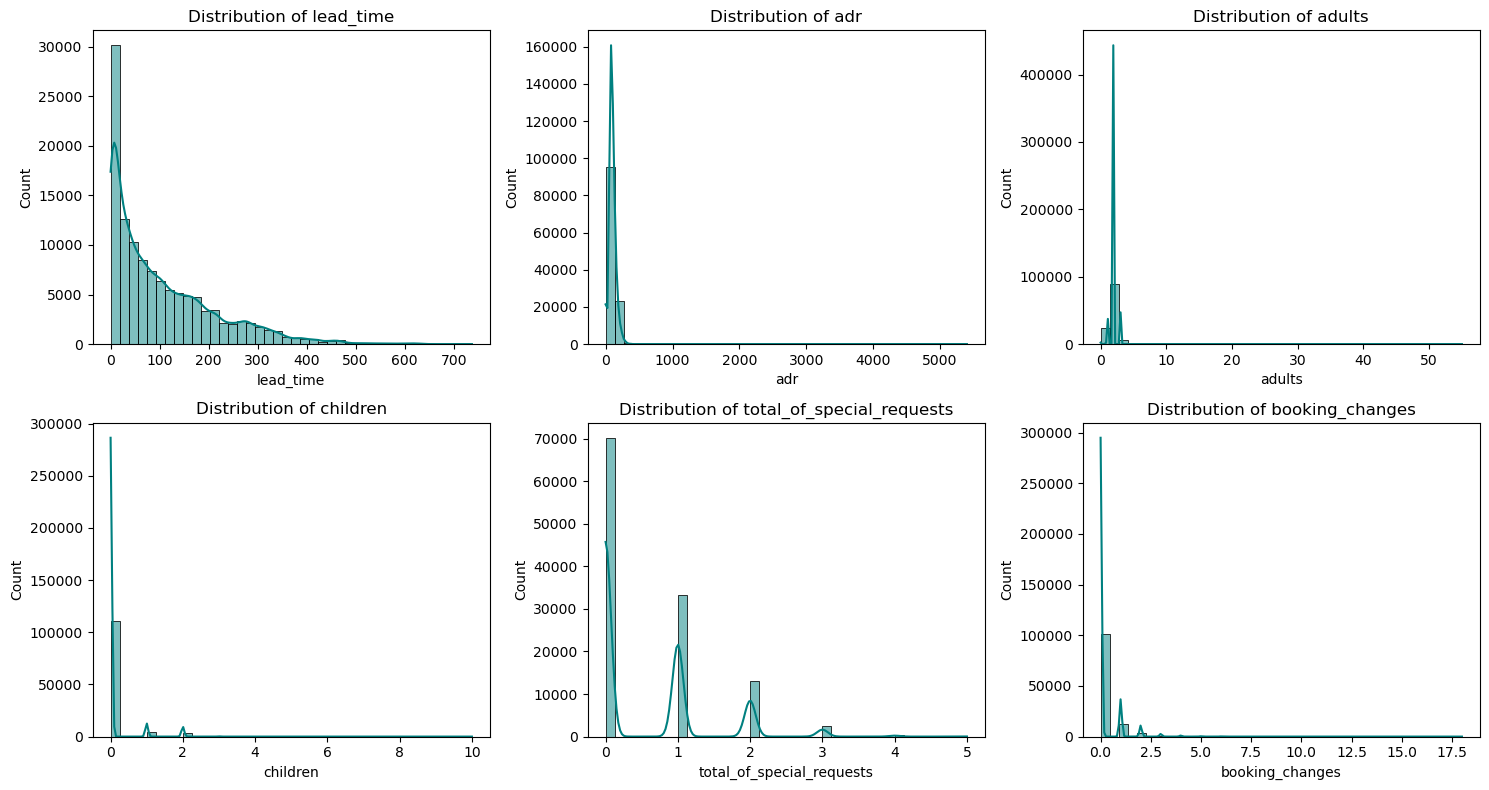

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

key_cols = ['lead_time', 'adr', 'adults', 'children',
            'total_of_special_requests', 'booking_changes']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.ravel()

for i, col in enumerate(key_cols):
    sns.histplot(data=df, x=col, kde=True, ax=axes[i],
                 bins=40, color='teal')
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')

plt.tight_layout()
plt.show()

# Q12) Outliers


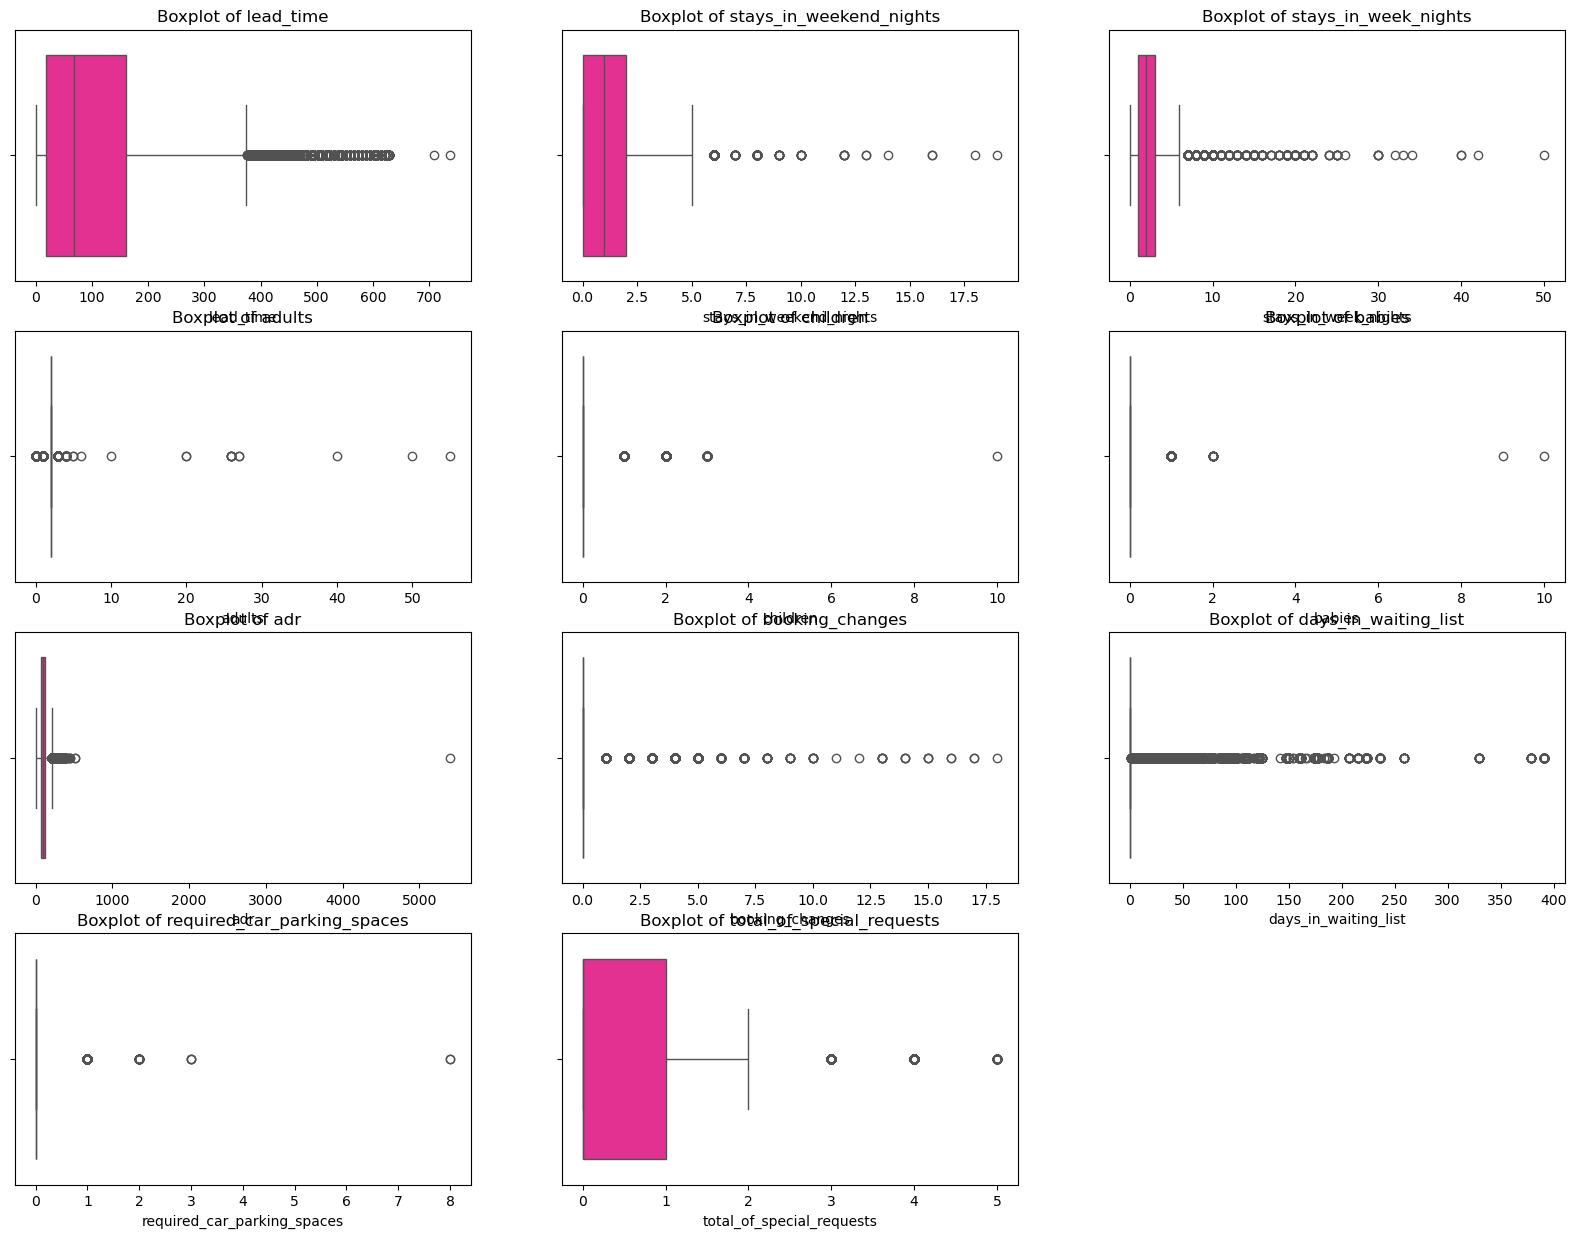

In [35]:

plt.figure(figsize=(20, 15))
for i, col in enumerate(num_cols, 1):
  plt.subplot(4, 3, i)
  sns.boxplot(x=df[col],  color='deeppink')
  plt.title(f'Boxplot of {col}')

plt.show()

## Q13) Categorical summary
# Top 10 value counts for each categorical column

In [36]:
from IPython.display import display

for col in ['country', 'customer_segment', 'meal']:
    counts = df[col].value_counts()
    percentages = (df[col].value_counts(normalize=True) * 100).round(2)

    summary = pd.DataFrame({
        'Value': counts.index,
        'Count': counts.values,
        'Percentage (%)': percentages.values
    })

    print(f"\nUpdated Distribution for: {col}")
    display(summary)


Updated Distribution for: country


,Value,Count,Percentage (%)
0,PRT,48961,41.07
1,GBR,12119,10.17
2,FRA,10401,8.73
3,ESP,8560,7.18
4,DEU,7285,6.11
...,...,...,...
172,MRT,1,0.00
173,KIR,1,0.00
174,SDN,1,0.00
175,ATF,1,0.00



Updated Distribution for: customer_segment


,Value,Count,Percentage (%)
0,Online TA,56408,47.32
1,Offline TA/TO,24182,20.29
2,Groups,19790,16.60
3,Direct,12582,10.55
4,Corporate,5282,4.43
5,Complementary,728,0.61
6,Aviation,235,0.20
7,Undefined,2,0.00



Updated Distribution for: meal


,Value,Count,Percentage (%)
0,BB,92235,77.37
1,HB,14458,12.13
2,SC,11718,9.83
3,FB,798,0.67


In [37]:
cat_cols = [
    'hotel',
    'meal',
    'country',
    'customer_segment',
    'booking_channel',
    'deposit_type',
    'customer_type',
    'reserved_room_type',
    'assigned_room_type',
    'reservation_status'
]

summary_rows = []

for col in cat_cols:
    if col in df.columns:
        top = df[col].value_counts(dropna=False).head(8).reset_index()
        top.columns = ['Value', 'Count']
        top['Column'] = col
        top['Percentage'] = (top['Count'] / len(df) * 100).round(1)
        summary_rows.append(top[['Column', 'Value', 'Count', 'Percentage']])

top_categories = pd.concat(summary_rows, ignore_index=True)

top_categories.style \
    .format({'Count': '{:,}', 'Percentage': '{:.1f}%'}) \
    .background_gradient(subset=['Count'], cmap='Blues')

,Column,Value,Count,Percentage
0,hotel,City Hotel,"79,163",66.4%
1,hotel,Resort Hotel,"40,046",33.6%
2,meal,BB,"92,235",77.4%
3,meal,HB,"14,458",12.1%
4,meal,SC,"11,718",9.8%
5,meal,FB,798,0.7%
6,country,PRT,"48,961",41.1%
7,country,GBR,"12,119",10.2%
8,country,FRA,"10,401",8.7%
9,country,ESP,"8,560",7.2%


In [38]:
##save data
df.to_csv('cleaned_data.csv', index=False)

## Q13) Categorical summary: what are the top categories?

In [39]:
drop_cols = [
    'name','email','phone-number','credit_card',
    'reservation_status','reservation_status_date',
    'arrival_date_week_number','arrival_date_day_of_month'
]

df = df.drop(columns=drop_cols)

In [40]:
cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols:
    print(f"\n===== {col} =====\n")
    
    x = df[col].value_counts().head(10)
    y = round((x / len(df)) * 100,2)
    frequent = pd.DataFrame({
        "count": x,
        "percentage": y
    })
    
    print(frequent)


===== hotel =====

              count  percentage
hotel                          
City Hotel    79163       66.41
Resort Hotel  40046       33.59

===== arrival_date_month =====

                    count  percentage
arrival_date_month                   
August              13861       11.63
July                12644       10.61
May                 11780        9.88
October             11147        9.35
April               11078        9.29
June                10929        9.17
September           10500        8.81
March                9767        8.19
February             8052        6.75
November             6771        5.68

===== meal =====

      count  percentage
meal                   
BB    92235       77.37
HB    14458       12.13
SC    11718        9.83
FB      798        0.67

===== country =====

         count  percentage
country                   
PRT      48961       41.07
GBR      12119       10.17
FRA      10401        8.73
ESP       8560        7.18
DEU       7285  

## Q14) Rare categories: do we have categories that appear very few times?

In [41]:
for col in cat_cols:
    print(f"\n===== {col} =====\n")
    
    x = df[col].value_counts()
    y = round((x / len(df)) * 100,2)
    frequent = pd.DataFrame({
        "count": x,
        "percentage": y
    })
    
    rare = frequent[frequent["percentage"] < 3.00]
    
    if not rare.empty:
        print("Rare categories (<3%):")
        print(rare)
    else:
        print("No rare categories (<3%)\n")


===== hotel =====

No rare categories (<3%)


===== arrival_date_month =====

No rare categories (<3%)


===== meal =====

Rare categories (<3%):
      count  percentage
meal                   
FB      798        0.67

===== country =====

Rare categories (<3%):
         count  percentage
country                   
IRL       3374        2.83
BEL       2342        1.96
BRA       2222        1.86
NLD       2103        1.76
USA       2093        1.76
...        ...         ...
MRT          1        0.00
KIR          1        0.00
SDN          1        0.00
ATF          1        0.00
SLE          1        0.00

[171 rows x 2 columns]

===== customer_segment =====

Rare categories (<3%):
                  count  percentage
customer_segment                   
Complementary       728        0.61
Aviation            235        0.20
Undefined             2        0.00

===== booking_channel =====

Rare categories (<3%):
                 count  percentage
booking_channel                   
GDS 

## Q15) Numeric relationships: which numeric columns move together?


## Q19) Multivariate heatmap: visualize relationships clearly

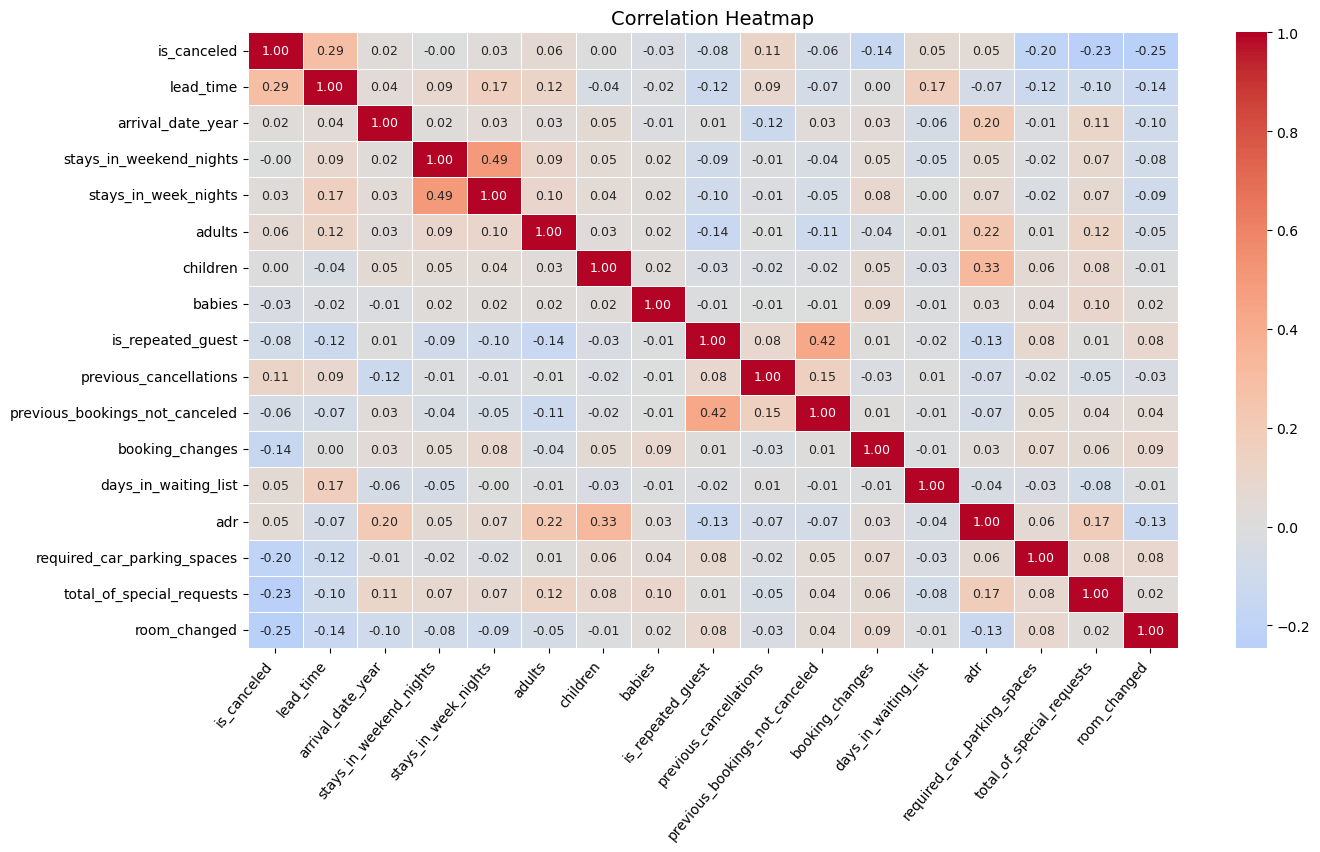

In [42]:
num_df = df.select_dtypes(include=['int64','float64'])
corr = num_df.corr()

plt.figure(figsize=(15,8))
sns.heatmap(
    corr,
    annot=True,          
    fmt=".2f",          
    cmap="coolwarm",    
    center=0,           
    linewidths=0.5,      
    annot_kws={"size":9}
)

plt.title("Correlation Heatmap", fontsize=14)
plt.xticks(rotation=50, ha='right')
plt.yticks(rotation=0)

plt.show()

In [43]:
corr_pairs = (
    corr.abs()
    .unstack()
    .sort_values(ascending=False)
)

top5 = corr_pairs[corr_pairs < 1].drop_duplicates().head(5)

top5

stays_in_weekend_nights  stays_in_week_nights              0.494154
is_repeated_guest        previous_bookings_not_canceled    0.420641
adr                      children                          0.325060
lead_time                is_canceled                       0.292883
room_changed             is_canceled                       0.246759
dtype: float64

## Q16) Visual check: scatter plots for key numeric pairs

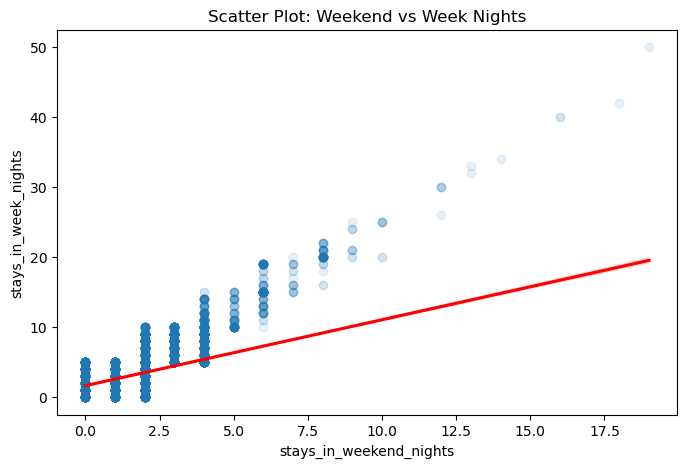

In [44]:
# Trend Line
plt.figure(figsize=(8, 5))
sns.regplot(data=df, x='stays_in_weekend_nights', y='stays_in_week_nights', 
            scatter_kws={'alpha':0.1}, line_kws={'color':'red'})
plt.title('Scatter Plot: Weekend vs Week Nights')
plt.show()

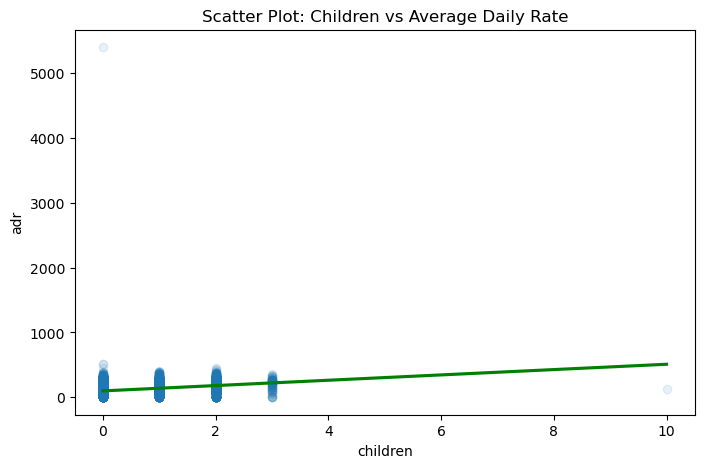

In [45]:
plt.figure(figsize=(8, 5))
sns.regplot(data=df, x='children', y='adr', 
            scatter_kws={'alpha':0.1}, line_kws={'color':'green'})
plt.title('Scatter Plot: Children vs Average Daily Rate')
plt.show()

## Q17) Category → numeric effect: does numeric change by category?

In [46]:
df.groupby('customer_segment')['adr'].agg(['mean','median']).sort_values(by='mean',ascending=False)

,mean,median
customer_segment,,
Online TA,117.318022,109.8
Direct,115.634595,105.0
Aviation,100.994383,95.0
Offline TA/TO,87.479307,85.5
Groups,79.563963,70.0
Corporate,69.528332,65.0
Undefined,15.000000,15.0
Complementary,2.945838,0.0


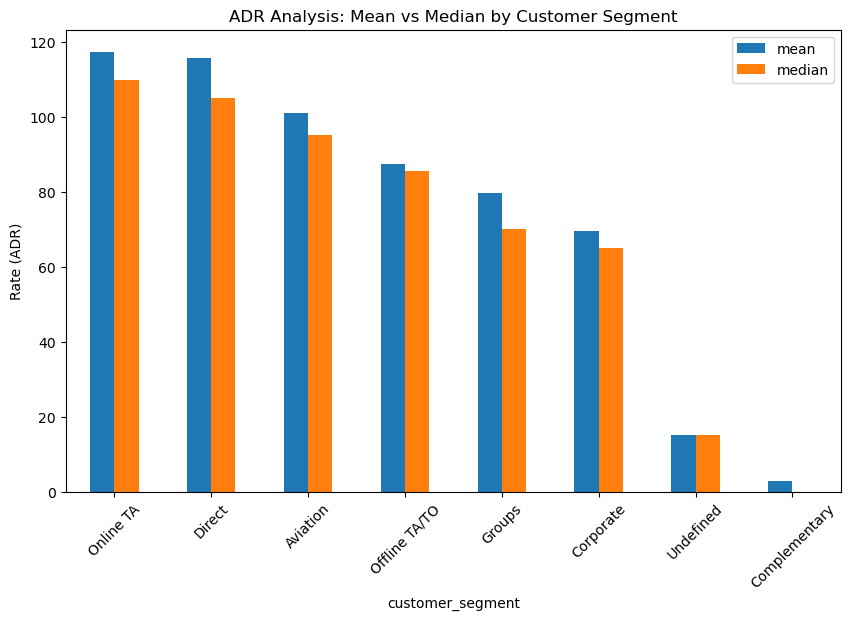

In [47]:
stats = df.groupby('customer_segment')['adr'].agg(['mean', 'median']).sort_values(by='mean', ascending=False)
stats.plot(kind='bar', figsize=(10, 6))
plt.title('ADR Analysis: Mean vs Median by Customer Segment')
plt.ylabel('Rate (ADR)')
plt.xticks(rotation=45)
plt.show()

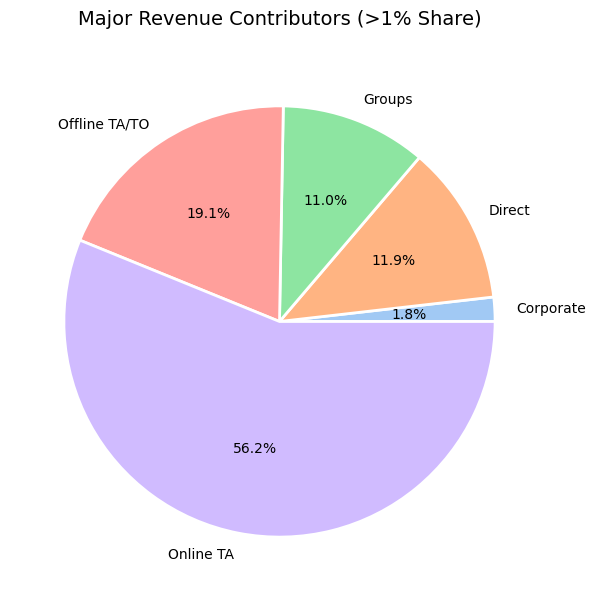

In [48]:
df['total_revenue'] = df['adr'] * (df['stays_in_weekend_nights'] + df['stays_in_week_nights'])
revenue_share = df.groupby('customer_segment')['total_revenue'].sum()

revenue_filtered = revenue_share[revenue_share > (revenue_share.sum() * 0.01)]

plt.figure(figsize=(10, 7))
colors = sns.color_palette('pastel', len(revenue_filtered))

revenue_filtered.plot(kind='pie', autopct='%1.1f%%',  colors=colors,
                      wedgeprops={'edgecolor': 'white', 'linewidth': 2})

plt.title('Major Revenue Contributors (>1% Share)', fontsize=14, pad=20)
plt.ylabel('')
plt.show()




## Q18) Category ↔ category relationship (if possible)

In [49]:
pd.crosstab(df['hotel'], df['booking_channel'])

booking_channel,Corporate,Direct,GDS,TA/TO,Undefined
hotel,,,,,
City Hotel,3386,6749,193,68831,4
Resort Hotel,3265,7861,0,28919,1


## Q20) Final EDA summary (simple but complete)